# Supporting Analysis for Scout Product Prioritization

This notebook supports the separate one-page decision memo. The analysis uses the UCI Online Retail dataset to identify products Scout should prioritize for personalized recommendations and price-drop alerts.

## Prepare the dataset

In [2]:
!pip install openpyxl


[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_excel("data/Online Retail.xlsx", engine="openpyxl")

print(df.shape)
display(df.head())
df.info()

(541909, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[us]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 40.0+ MB


## Clean the dataset

In [8]:
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

df.head()

,invoiceno,stockcode,description,quantity,invoicedate,unitprice,customerid,country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [9]:
print(df.shape)
df.info()

(541909, 8)
<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   invoiceno    541909 non-null  object        
 1   stockcode    541909 non-null  object        
 2   description  540455 non-null  object        
 3   quantity     541909 non-null  int64         
 4   invoicedate  541909 non-null  datetime64[us]
 5   unitprice    541909 non-null  float64       
 6   customerid   406829 non-null  float64       
 7   country      541909 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 40.0+ MB


In [10]:
df.isna().sum()

invoiceno           0
stockcode           0
description      1454
quantity            0
invoicedate         0
unitprice           0
customerid     135080
country             0
dtype: int64

In [11]:
df.describe()

,quantity,invoicedate,unitprice,customerid
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303


### The dataset contains negative quantities and negative unit prices, which likely represent cancellations, returns, or data adjustments. These rows are removed from the cleaned transaction dataset.

In [12]:
# Dataset cleaning

df_clean = df.copy()

# Convert invoice date to datetime
df_clean["invoicedate"] = pd.to_datetime(df_clean["invoicedate"])

# Remove cancelled invoices
df_clean = df_clean[~df_clean["invoiceno"].astype(str).str.startswith("C")]

# Remove invalid transactions
df_clean = df_clean[df_clean["quantity"] > 0]
df_clean = df_clean[df_clean["unitprice"] > 0]

# Create revenue
df_clean["revenue"] = df_clean["quantity"] * df_clean["unitprice"]

print(df_clean.shape)
display(df_clean.head())
df_clean.describe()

(530104, 9)


,invoiceno,stockcode,description,quantity,invoicedate,unitprice,customerid,country,revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


,quantity,invoicedate,unitprice,customerid,revenue
count,530104.000000,530104,530104.000000,397884.000000,530104.000000
mean,10.542037,2011-07-04 20:16:05.225087,3.907625,15294.423453,20.121871
min,1.000000,2010-12-01 08:26:00,0.001000,12346.000000,0.001000
25%,1.000000,2011-03-28 12:22:00,1.250000,13969.000000,3.750000
50%,3.000000,2011-07-20 12:58:00,2.080000,15159.000000,9.900000
75%,10.000000,2011-10-19 12:39:00,4.130000,16795.000000,17.700000
max,80995.000000,2011-12-09 12:50:00,13541.330000,18287.000000,168469.600000
std,155.524124,NaN,35.915681,1713.141560,270.356743


In [13]:
df_clean.isna().sum()

invoiceno           0
stockcode           0
description         0
quantity            0
invoicedate         0
unitprice           0
customerid     132220
country             0
revenue             0
dtype: int64

### Check the extreme value and remove non-product orders

In [19]:
# Explore more on extreme values

cols_to_show = [
    "invoiceno", "stockcode", "description", 
    "quantity", "unitprice", "revenue", 
    "customerid", "country"
]

cols_to_check = ["quantity", "unitprice", "revenue"]

for col in cols_to_check:
    print(f"\n===== {col.upper()} - LOWEST 10 =====")
    display(
        df_clean
        .sort_values(col, ascending=True)
        .head(10)[cols_to_show]
    )
    
    print(f"\n===== {col.upper()} - HIGHEST 10 =====")
    display(
        df_clean
        .sort_values(col, ascending=False)
        .head(10)[cols_to_show]
    )


===== QUANTITY - LOWEST 10 =====


,invoiceno,stockcode,description,quantity,unitprice,revenue,customerid,country
541842,581580,20974,12 PENCILS SMALL TUBE SKULL,1,0.65,0.65,12748.0,United Kingdom
151572,549560,48138,DOORMAT UNION FLAG,1,7.95,7.95,15058.0,United Kingdom
455118,575607,22812,PACK 3 BOXES CHRISTMAS PANNETONE,1,4.13,4.13,14096.0,United Kingdom
455111,575607,22752,SET 7 BABUSHKA NESTING BOXES,1,16.63,16.63,14096.0,United Kingdom
455110,575607,22745,POPPY'S PLAYHOUSE BEDROOM,1,4.13,4.13,14096.0,United Kingdom
455109,575607,22743,MAKE YOUR OWN FLOWERPOWER CARD KIT,1,5.79,5.79,14096.0,United Kingdom
455107,575607,22738,RIBBON REEL SNOWY VILLAGE,1,3.29,3.29,14096.0,United Kingdom
455105,575607,22736,RIBBON REEL MAKING SNOWMEN,1,3.29,3.29,14096.0,United Kingdom
151544,549558,20845,ZINC HEART LATTICE 2 WALL PLANTER,1,6.35,6.35,15058.0,United Kingdom
151543,549558,84789,ENCHANTED BIRD PLANT CAGE,1,3.75,3.75,15058.0,United Kingdom



===== QUANTITY - HIGHEST 10 =====


,invoiceno,stockcode,description,quantity,unitprice,revenue,customerid,country
540421,581483,23843,"PAPER CRAFT , LITTLE BIRDIE",80995,2.08,168469.60,16446.0,United Kingdom
61619,541431,23166,MEDIUM CERAMIC TOP STORAGE JAR,74215,1.04,77183.60,12346.0,United Kingdom
421632,573008,84077,WORLD WAR 2 GLIDERS ASSTD DESIGNS,4800,0.21,1008.00,12901.0,United Kingdom
206121,554868,22197,SMALL POPCORN HOLDER,4300,0.72,3096.00,13135.0,United Kingdom
97432,544612,22053,EMPIRE DESIGN ROSETTE,3906,0.82,3202.92,18087.0,United Kingdom
270885,560599,18007,ESSENTIAL BALM 3.5g TIN IN ENVELOPE,3186,0.06,191.16,14609.0,United Kingdom
160546,550461,21108,FAIRY CAKE FLANNEL ASSORTED COLOUR,3114,2.10,6539.40,15749.0,United Kingdom
52711,540815,21108,FAIRY CAKE FLANNEL ASSORTED COLOUR,3114,2.10,6539.40,15749.0,United Kingdom
433788,573995,16014,SMALL CHINESE STYLE SCISSOR,3000,0.32,960.00,16308.0,United Kingdom
291249,562439,84879,ASSORTED COLOUR BIRD ORNAMENT,2880,1.45,4176.00,12931.0,United Kingdom



===== UNITPRICE - LOWEST 10 =====


...

,invoiceno,stockcode,description,quantity,unitprice,revenue,customerid,country
15017,537632,AMAZONFEE,AMAZON FEE,1,13541.33,13541.33,NaN,United Kingdom
299982,A563185,B,Adjust bad debt,1,11062.06,11062.06,NaN,United Kingdom
173382,551697,POST,POSTAGE,1,8142.75,8142.75,16029.0,United Kingdom
297723,562955,DOT,DOTCOM POSTAGE,1,4505.17,4505.17,NaN,United Kingdom
268028,560373,M,Manual,1,4287.63,4287.63,NaN,United Kingdom
422376,573080,M,Manual,1,4161.06,4161.06,12536.0,France
422351,573077,M,Manual,1,4161.06,4161.06,12536.0,France
406406,571751,M,Manual,1,3949.32,3949.32,12744.0,Singapore
374542,569382,M,Manual,1,3155.95,3155.95,15502.0,United Kingdom
347948,567353,M,Manual,1,2653.95,2653.95,NaN,Hong Kong



===== REVENUE - LOWEST 10 =====


,invoiceno,stockcode,description,quantity,unitprice,revenue,customerid,country
279045,561226,PADS,PADS TO MATCH ALL CUSHIONS,1,0.001,0.001,15618.0,United Kingdom
361741,568375,BANK CHARGES,Bank Charges,1,0.001,0.001,13405.0,United Kingdom
157195,550193,PADS,PADS TO MATCH ALL CUSHIONS,1,0.001,0.001,13952.0,United Kingdom
359871,568200,PADS,PADS TO MATCH ALL CUSHIONS,1,0.001,0.001,16198.0,United Kingdom
423991,573174,16218,CARTOON PENCIL SHARPENERS,1,0.060,0.060,NaN,United Kingdom
500313,578757,16216,LETTER SHAPE PENCIL SHARPENER,1,0.060,0.060,12748.0,United Kingdom
285080,561894,M,Manual,1,0.080,0.080,14456.0,United Kingdom
241349,558198,17038,PORCELAIN BUDAH INCENSE HOLDER,1,0.100,0.100,14104.0,United Kingdom
497822,578479,17038,PORCELAIN BUDAH INCENSE HOLDER,1,0.100,0.100,15858.0,United Kingdom
257038,559509,17038,PORCELAIN BUDAH INCENSE HOLDER,1,0.100,0.100,15920.0,United Kingdom



===== REVENUE - HIGHEST 10 =====


,invoiceno,stockcode,description,quantity,unitprice,revenue,customerid,country
540421,581483,23843,"PAPER CRAFT , LITTLE BIRDIE",80995,2.08,168469.60,16446.0,United Kingdom
61619,541431,23166,MEDIUM CERAMIC TOP STORAGE JAR,74215,1.04,77183.60,12346.0,United Kingdom
222680,556444,22502,PICNIC BASKET WICKER 60 PIECES,60,649.50,38970.00,15098.0,United Kingdom
15017,537632,AMAZONFEE,AMAZON FEE,1,13541.33,13541.33,NaN,United Kingdom
299982,A563185,B,Adjust bad debt,1,11062.06,11062.06,NaN,United Kingdom
173382,551697,POST,POSTAGE,1,8142.75,8142.75,16029.0,United Kingdom
348325,567423,23243,SET OF TEA COFFEE SUGAR TINS PANTRY,1412,5.06,7144.72,17450.0,United Kingdom
52711,540815,21108,FAIRY CAKE FLANNEL ASSORTED COLOUR,3114,2.10,6539.40,15749.0,United Kingdom
160546,550461,21108,FAIRY CAKE FLANNEL ASSORTED COLOUR,3114,2.10,6539.40,15749.0,United Kingdom
421601,573003,23084,RABBIT NIGHT LIGHT,2400,2.08,4992.00,14646.0,Netherlands


Orders like POSTAGE, DOTCOM POSTAGE, AMAZON FEE, BANK CHARGE and so on should not be included into production recommendation.

In [20]:
df_product = df_clean.copy()

In [24]:
non_product_descriptions = [
    "POSTAGE",
    "DOTCOM POSTAGE",
    "AMAZON FEE",
    "BANK CHARGES",
    "Adjust bad debt",
    "Manual"
]

non_product_stockcodes = [
    "POST",
    "DOT",
    "M",
    "B",
    "AMAZONFEE",
    "BANK CHARGES"
]

description_pattern = "|".join(non_product_descriptions)

non_product_rows = df_clean[
    df_clean["description"].astype(str).str.contains(description_pattern, case=False, na=False)
    | df_clean["stockcode"].astype(str).isin(non_product_stockcodes)
].copy()

print("Non-product rows:", len(non_product_rows))
print("Non-product revenue:", round(non_product_rows["revenue"].sum(), 2))

display(
    non_product_rows
    .groupby(["stockcode", "description"])
    .agg(
        rows=("invoiceno", "count"),
        revenue=("revenue", "sum")
    )
    .reset_index()
    .sort_values("revenue", ascending=False)
    .head(30)
)

Non-product rows: 2169
Non-product revenue: 387451.62


,stockcode,description,rows,revenue
3,DOT,DOTCOM POSTAGE,706,206248.770
4,M,Manual,321,78110.270
5,POST,POSTAGE,1126,78101.880
0,AMAZONFEE,AMAZON FEE,2,13761.090
1,B,Adjust bad debt,1,11062.060
2,BANK CHARGES,Bank Charges,12,165.001
6,m,Manual,1,2.550


In [25]:
df_product = df_clean.drop(non_product_rows.index).copy()

print("Clean transaction rows:", len(df_clean))
print("Product analysis rows:", len(df_product))
print("Removed rows:", len(non_product_rows))
print("Removed revenue:", round(non_product_rows["revenue"].sum(), 2))
print("Removed row share:", round(len(non_product_rows) / len(df_clean), 4))
print("Removed revenue share:", round(non_product_rows["revenue"].sum() / df_clean["revenue"].sum(), 4))

Clean transaction rows: 530104
Product analysis rows: 527935
Removed rows: 2169
Removed revenue: 387451.62
Removed row share: 0.0041
Removed revenue share: 0.0363


In [26]:
low_price_rows = df_product[df_product["unitprice"] < 0.1]

print("Rows with unit price < 0.1:", len(low_price_rows))
print("Revenue from unit price < 0.1:", low_price_rows["revenue"].sum())
print("Share of product revenue:", low_price_rows["revenue"].sum() / df_product["revenue"].sum())

display(
    low_price_rows
    .groupby(["stockcode", "description"])
    .agg(
        rows=("invoiceno", "count"),
        total_quantity=("quantity", "sum"),
        total_revenue=("revenue", "sum"),
        avg_unitprice=("unitprice", "mean")
    )
    .reset_index()
    .sort_values("total_revenue", ascending=False)
    .head(20)
)

Rows with unit price < 0.1: 238
Revenue from unit price < 0.1: 1706.953
Share of product revenue: 0.00016605840268301116


,stockcode,description,rows,total_quantity,total_revenue,avg_unitprice
2,16045,POPART WOODEN PENCILS ASST,66,8600,344.000,0.040
8,18007,ESSENTIAL BALM 3.5g TIN IN ENVELOPE,2,5586,335.160,0.060
6,16259,PIECE OF CAMO STATIONERY SET,27,2948,235.840,0.080
4,16218,CARTOON PENCIL SHARPENERS,45,3431,205.860,0.060
0,15034,PAPER POCKET TRAVELING FAN,4,2880,201.600,0.070
3,16216,LETTER SHAPE PENCIL SHARPENER,30,2988,179.280,0.060
5,16219,HOUSE SHAPE PENCIL SHARPENER,38,2003,120.180,0.060
10,17136A,BLUE STONES ON WIRE FOR CANDLE,17,393,31.440,0.080
7,17038,PORCELAIN BUDAH INCENSE HOLDER,3,400,28.000,0.070
1,16008,SMALL FOLDING SCISSOR(POINTED EDGE),1,240,19.200,0.080


Check low price products to make sure they didn't took large share of revenue because of low unit price and high quantity.

## Analysis most popular and expensive products

In [27]:
product_summary = (
    df_product
    .groupby("description")
    .agg(
        total_revenue=("revenue", "sum"),
        total_quantity=("quantity", "sum"),
        order_count=("invoiceno", "nunique"),
        avg_unit_price=("unitprice", "mean")
    )
    .reset_index()
    .sort_values("total_revenue", ascending=False)
)

product_summary["revenue_share"] = (
    product_summary["total_revenue"] / product_summary["total_revenue"].sum()
)

display(product_summary.head(15))

,description,total_revenue,total_quantity,order_count,avg_unit_price,revenue_share
2847,REGENCY CAKESTAND 3 TIER,174484.74,13879,1988,13.976926,0.016974
2382,"PAPER CRAFT , LITTLE BIRDIE",168469.60,80995,1,2.080000,0.016389
3838,WHITE HANGING HEART T-LIGHT HOLDER,106292.77,37891,2256,3.216948,0.010341
2408,PARTY BUNTING,99504.33,18295,1685,5.794273,0.009680
1812,JUMBO BAG RED RETROSPOT,94340.05,48474,2089,2.485459,0.009178
2048,MEDIUM CERAMIC TOP STORAGE JAR,81700.92,78033,247,1.468480,0.007948
2735,RABBIT NIGHT LIGHT,66964.99,30788,994,2.380502,0.006515
2376,PAPER CHAIN KIT 50'S CHRISTMAS,64952.29,19355,1160,3.356833,0.006319
226,ASSORTED COLOUR BIRD ORNAMENT,59094.93,36461,1455,1.722290,0.005749
745,CHILLI LIGHTS,54117.76,10306,661,6.789522,0.005265


In [28]:
high_price_products = (
    df_product
    .groupby("description")
    .agg(
        total_revenue=("revenue", "sum"),
        total_quantity=("quantity", "sum"),
        order_count=("invoiceno", "nunique"),
        avg_unit_price=("unitprice", "mean")
    )
    .reset_index()
)

high_price_products = high_price_products[
    high_price_products["order_count"] >= 10
].sort_values("avg_unit_price", ascending=False)

display(high_price_products.head(15))

,description,total_revenue,total_quantity,order_count,avg_unit_price
2966,RUSTIC SEVENTEEN DRAWER SIDEBOARD,5415.00,35,26,158.076923
3691,VINTAGE BLUE KITCHEN CABINET,3685.00,26,20,146.750000
3740,VINTAGE RED KITCHEN CABINET,8125.00,60,38,143.421053
712,CHEST NATURAL WOOD 20 DRAWERS,2745.00,24,13,118.076923
1988,LOVE SEAT ANTIQUE WHITE METAL,6210.00,58,41,114.024390
3003,SCHOOL DESK AND CHAIR,1199.75,19,13,63.915385
654,CARRIAGE,7051.00,142,141,49.879433
802,CINDERELLA CHANDELIER,3717.56,221,23,45.487391
3262,SET/4 WHITE RETRO STORAGE CUBES,16363.30,415,155,45.232258
944,DANISH ROSE BEDSIDE CABINET,519.35,13,10,39.950000


In [29]:
recommended_products = product_summary[
    product_summary["order_count"] >= 100
].copy()

recommended_products["revenue_rank"] = recommended_products["total_revenue"].rank(ascending=False)
recommended_products["order_rank"] = recommended_products["order_count"].rank(ascending=False)
recommended_products["quantity_rank"] = recommended_products["total_quantity"].rank(ascending=False)

recommended_products["recommendation_score"] = (
    recommended_products["revenue_rank"] * 0.5
    + recommended_products["order_rank"] * 0.3
    + recommended_products["quantity_rank"] * 0.2
)

recommended_products = recommended_products.sort_values("recommendation_score")

display(recommended_products.head(15))

,description,total_revenue,total_quantity,order_count,avg_unit_price,revenue_share,revenue_rank,order_rank,quantity_rank,recommendation_score
3838,WHITE HANGING HEART T-LIGHT HOLDER,106292.77,37891,2256,3.216948,0.010341,2.0,1.0,4.0,2.1
1812,JUMBO BAG RED RETROSPOT,94340.05,48474,2089,2.485459,0.009178,4.0,2.0,3.0,3.2
2408,PARTY BUNTING,99504.33,18295,1685,5.794273,0.009680,3.0,4.0,20.0,6.7
226,ASSORTED COLOUR BIRD ORNAMENT,59094.93,36461,1455,1.722290,0.005749,8.0,6.0,6.0,7.0
2847,REGENCY CAKESTAND 3 TIER,174484.74,13879,1988,13.976926,0.016974,1.0,3.0,39.0,9.2
2376,PAPER CHAIN KIT 50'S CHRISTMAS,64952.29,19355,1160,3.356833,0.006319,7.0,16.0,18.0,11.9
1810,JUMBO BAG PINK POLKADOT,42436.24,21465,1218,2.596115,0.004128,11.0,11.0,16.0,12.0
1999,LUNCH BAG RED RETROSPOT,35752.01,19353,1564,2.127798,0.003478,17.0,5.0,19.0,13.8
2735,RABBIT NIGHT LIGHT,66964.99,30788,994,2.380502,0.006515,6.0,33.0,8.0,14.5
1658,HEART OF WICKER SMALL,32107.80,17971,1201,1.957945,0.003124,24.0,12.0,23.0,20.2


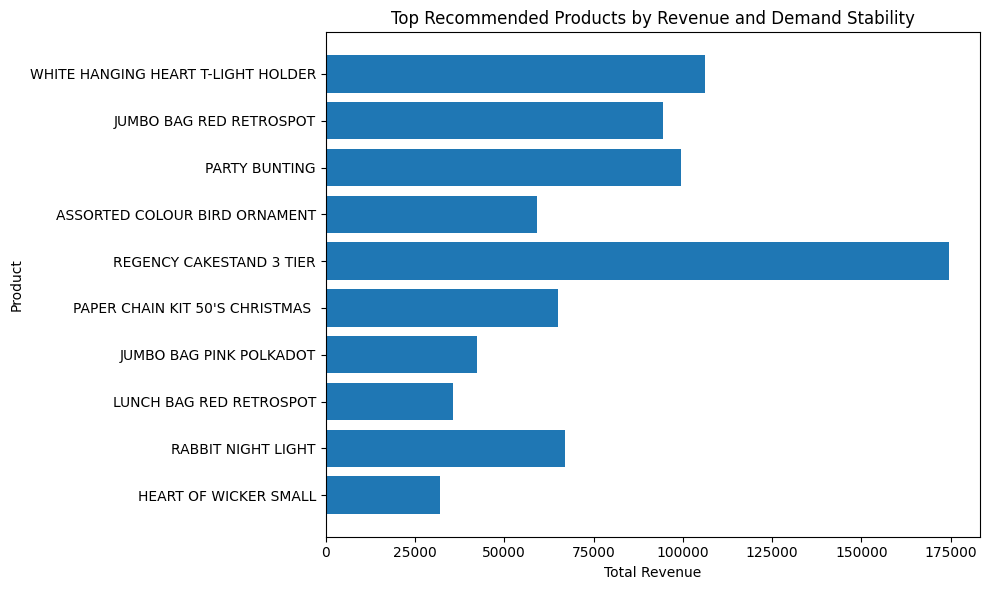

In [ ]:
top_recommended = recommended_products.head(10)

plt.figure(figsize=(10, 6))
plt.barh(top_recommended["description"], top_recommended["total_revenue"])
plt.gca().invert_yaxis()
plt.xlabel("Total Revenue")
plt.ylabel("Product")
plt.title("Top Recommended Products by Recommendation Score")
plt.tight_layout()
plt.show()

The Top recommend products are not only decide by total revenue, the demand volume is also necessary, using recommendation score is to avoid focus on luxury with low market demand.

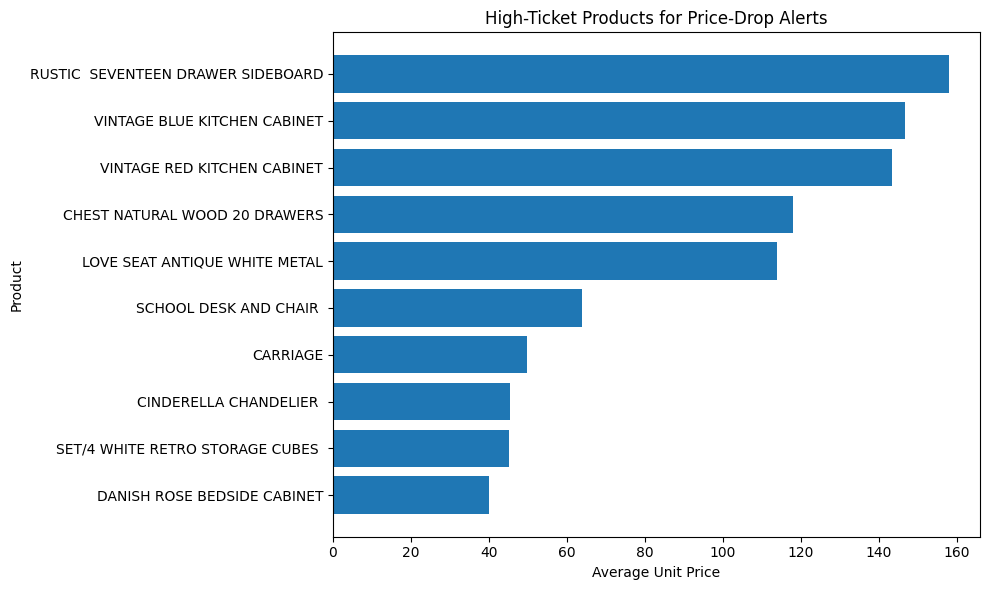

In [31]:
top_price_alerts = high_price_products.head(10)

plt.figure(figsize=(10, 6))
plt.barh(top_price_alerts["description"], top_price_alerts["avg_unit_price"])
plt.gca().invert_yaxis()
plt.xlabel("Average Unit Price")
plt.ylabel("Product")
plt.title("High-Ticket Products for Price-Drop Alerts")
plt.tight_layout()
plt.show()

For price-drop alerts, products with higher average unit prices should be considered, but the times of order should also be considered. In this project we choose high price target with at least 10 orders as target. These products are more likely to benefit from price tracking due to they keep a certain market demand.

## Summary

The analysis supports the decision memo recommendation that Scout should separate product prioritization into two tracks: high-demand products for recommendations and high-ticket products for price-drop alerts. The final business recommendation is summarized in the separate one-page decision memo.